# Desafio Final — Análise de Dados de Energia com API Pública

**Curso:** Ciência da Computação  
**Disciplina:** Soluções em Energias Renováveis e Sustentáveis

## Situação-problema

Uma equipe de planejamento energético precisa analisar o comportamento da carga elétrica de uma região atendida pelo Sistema Interligado Nacional (SIN).

Os dados serão obtidos diretamente de uma API pública do **Operador Nacional do Sistema Elétrico (ONS)**. A conexão com a API e a preparação inicial do JSON já estão fornecidas. A partir daí, sua equipe deverá construir o DataFrame, organizar os dados, criar recortes, calcular indicadores, produzir gráficos e elaborar um relatório técnico.

> Todos os códigos, resultados, gráficos e respostas devem permanecer neste mesmo Notebook.

## 1. Fonte dos dados

API pública de **Carga Verificada do ONS**:

- Portal: https://dados.ons.org.br/
- Conjunto de dados: https://dados.ons.org.br/dataset/carga-energia-verificada

Neste notebook será utilizada inicialmente a área **SP — São Paulo**, no período de **01/08/2025 a 07/08/2025**.

## 2. Bibliotecas

In [4]:
import requests
import pandas as pd
import matplotlib.pyplot as plt

## 3. Consulta à API

Esta célula está pronta. Não é necessário conhecer `requests` para realizar o desafio.

In [5]:
url = "https://apicarga.ons.org.br/prd/cargaverificada"

parametros = {
    "dat_inicio": "2025-08-01",
    "dat_fim": "2025-08-07",
    "cod_areacarga": "SP"
}

response = requests.get(url, params=parametros, timeout=30)

print("Status:", response.status_code)
print("URL:", response.url)

response.raise_for_status()
dados_json = response.json()

Status: 200
URL: https://apicarga.ons.org.br/prd/cargaverificada?dat_inicio=2025-08-01&dat_fim=2025-08-07&cod_areacarga=SP


## 4. Preparação inicial do JSON

*   Item da lista
*   Item da lista



A célula abaixo localiza a lista principal de registros retornada pela API e a armazena em `registros`.

In [6]:
if isinstance(dados_json, list):
    registros = dados_json

elif isinstance(dados_json, dict):
    chaves_com_lista = [
        chave for chave, valor in dados_json.items()
        if isinstance(valor, list)
    ]

    if not chaves_com_lista:
        raise ValueError("A resposta não contém uma lista de registros.")

    chave_registros = chaves_com_lista[0]
    registros = dados_json[chave_registros]
    print("Chave utilizada:", chave_registros)

else:
    raise TypeError("Formato de JSON não reconhecido.")

print("Tipo:", type(registros))
print("Quantidade de registros:", len(registros))

if registros:
    print("\nPrimeiro registro:")
    print(registros[0])

Tipo: <class 'list'>
Quantidade de registros: 336

Primeiro registro:
{'cod_areacarga': 'SP', 'din_atualizacao': '2026-08-14T05:58:29.574Z', 'dat_referencia': '2025-08-01', 'din_referenciautc': '2025-08-01T03:30:00.000Z', 'val_cargaglobal': 15913.618, 'val_cargaglobalcons': 15913.618, 'val_cargaglobalsmmgd': 15892.488, 'val_cargasupervisionada': 14421.112, 'val_carganaosupervisionada': 1471.3759, 'val_cargammgd': 21.13, 'val_consistencia': 0}


In [7]:
registros

[{'cod_areacarga': 'SP',
  'din_atualizacao': '2026-08-14T05:58:29.574Z',
  'dat_referencia': '2025-08-01',
  'din_referenciautc': '2025-08-01T03:30:00.000Z',
  'val_cargaglobal': 15913.618,
  'val_cargaglobalcons': 15913.618,
  'val_cargaglobalsmmgd': 15892.488,
  'val_cargasupervisionada': 14421.112,
  'val_carganaosupervisionada': 1471.3759,
  'val_cargammgd': 21.13,
  'val_consistencia': 0},
 {'cod_areacarga': 'SP',
  'din_atualizacao': '2026-08-14T05:58:29.574Z',
  'dat_referencia': '2025-08-01',
  'din_referenciautc': '2025-08-01T04:00:00.000Z',
  'val_cargaglobal': 15251.414,
  'val_cargaglobalcons': 15251.414,
  'val_cargaglobalsmmgd': 15230.284,
  'val_cargasupervisionada': 13758.101,
  'val_carganaosupervisionada': 1472.184,
  'val_cargammgd': 21.13,
  'val_consistencia': 0},
 {'cod_areacarga': 'SP',
  'din_atualizacao': '2026-08-14T05:58:29.574Z',
  'dat_referencia': '2025-08-01',
  'din_referenciautc': '2025-08-01T04:30:00.000Z',
  'val_cargaglobal': 14606.733,
  'val_carga

# A partir daqui, o trabalho é da equipe

## DESAFIO 1 — Construção e inspeção do DataFrame

1. Crie um DataFrame Pandas chamado `dados` a partir de `registros`.
2. Exiba os primeiros registros.
3. Determine a quantidade de linhas e colunas.
4. Liste os nomes dos atributos.
5. Utilize `info()`.
6. Utilize `describe()`.
7. Em Markdown, identifique quais atributos representam data/hora, área de carga e valor de carga.

**Antes de prosseguir, compreenda a estrutura efetivamente retornada pela API.**

In [8]:
# Desenvolva aqui o DESAFIO 1

In [9]:
dados = pd.DataFrame(registros)
dados.head()

,cod_areacarga,din_atualizacao,dat_referencia,din_referenciautc,val_cargaglobal,val_cargaglobalcons,val_cargaglobalsmmgd,val_cargasupervisionada,val_carganaosupervisionada,val_cargammgd,val_consistencia
0,SP,2026-08-14T05:58:29.574Z,2025-08-01,2025-08-01T03:30:00.000Z,15913.618,15913.618,15892.488,14421.112,1471.3759,21.13,0
1,SP,2026-08-14T05:58:29.574Z,2025-08-01,2025-08-01T04:00:00.000Z,15251.414,15251.414,15230.284,13758.101,1472.1840,21.13,0
2,SP,2026-08-14T05:58:29.574Z,2025-08-01,2025-08-01T04:30:00.000Z,14606.733,14606.733,14585.604,13112.602,1473.0022,21.13,0
3,SP,2026-08-14T05:58:29.574Z,2025-08-01,2025-08-01T05:00:00.000Z,14182.290,14182.290,14161.160,12687.433,1473.7275,21.13,0
4,SP,2026-08-14T05:58:29.574Z,2025-08-01,2025-08-01T05:30:00.000Z,13838.488,13838.488,13817.358,12342.648,1474.7096,21.13,0


In [10]:
dados.shape

(336, 11)

In [11]:
dados.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 336 entries, 0 to 335
Data columns (total 11 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   cod_areacarga               336 non-null    object 
 1   din_atualizacao             336 non-null    object 
 2   dat_referencia              336 non-null    object 
 3   din_referenciautc           336 non-null    object 
 4   val_cargaglobal             336 non-null    float64
 5   val_cargaglobalcons         336 non-null    float64
 6   val_cargaglobalsmmgd        336 non-null    float64
 7   val_cargasupervisionada     336 non-null    float64
 8   val_carganaosupervisionada  336 non-null    float64
 9   val_cargammgd               336 non-null    float64
 10  val_consistencia            336 non-null    int64  
dtypes: float64(6), int64(1), object(4)
memory usage: 29.0+ KB


In [12]:
dados.describe()

,val_cargaglobal,val_cargaglobalcons,val_cargaglobalsmmgd,val_cargasupervisionada,val_carganaosupervisionada,val_cargammgd,val_consistencia
count,336.000000,336.000000,336.000000,336.000000,336.000000,336.000000,336.0
mean,17870.828981,17870.828981,16953.421626,15495.799695,1457.621862,917.407249,0.0
std,3029.042438,3029.042438,2962.721503,2982.650359,34.888571,1253.581141,0.0
min,12139.253000,12139.253000,11549.664000,10054.455000,1391.990800,21.130000,0.0
25%,15110.533375,15110.533375,14457.604250,12990.878500,1433.112575,21.130000,0.0
50%,18199.128500,18199.128500,17045.260000,15611.629500,1453.981650,21.196900,0.0
75%,20386.629500,20386.629500,18931.679500,17502.643500,1479.430775,1793.579475,0.0
max,23185.312000,23185.312000,23164.182000,21717.934000,1538.274700,3736.009800,0.0


In [13]:
# din_atualizaçao ---> Data e Hora
# val_cargaglobal ---> valor da carga
# cod_areacarga ---> área de carga

## DESAFIO 2 — Organização dos dados

1. Renomeie os principais atributos com nomes mais simples.
2. Crie um novo DataFrame contendo apenas os atributos necessários.
3. Verifique valores ausentes.
4. Caso existam, informe quantos há em cada atributo relevante.
5. Verifique se a variável de carga está em formato numérico.
6. Verifique como a data/hora está representada.
7. Registre em Markdown qualquer decisão de tratamento.

In [14]:
# Desenvolva aqui o DESAFIO 2
dados.rename({'cod_areacarga': 'CÓDIGO',
              'din_atualizacao': 'DATA E HORA ATUALIZADA',
              'val_cargaglobal': 'VAL. CARGA',
}, axis=1, inplace=True)
dados.head()

,CÓDIGO,DATA E HORA ATUALIZADA,dat_referencia,din_referenciautc,VAL. CARGA,val_cargaglobalcons,val_cargaglobalsmmgd,val_cargasupervisionada,val_carganaosupervisionada,val_cargammgd,val_consistencia
0,SP,2026-08-14T05:58:29.574Z,2025-08-01,2025-08-01T03:30:00.000Z,15913.618,15913.618,15892.488,14421.112,1471.3759,21.13,0
1,SP,2026-08-14T05:58:29.574Z,2025-08-01,2025-08-01T04:00:00.000Z,15251.414,15251.414,15230.284,13758.101,1472.1840,21.13,0
2,SP,2026-08-14T05:58:29.574Z,2025-08-01,2025-08-01T04:30:00.000Z,14606.733,14606.733,14585.604,13112.602,1473.0022,21.13,0
3,SP,2026-08-14T05:58:29.574Z,2025-08-01,2025-08-01T05:00:00.000Z,14182.290,14182.290,14161.160,12687.433,1473.7275,21.13,0
4,SP,2026-08-14T05:58:29.574Z,2025-08-01,2025-08-01T05:30:00.000Z,13838.488,13838.488,13817.358,12342.648,1474.7096,21.13,0


In [15]:
dados2 = dados.drop(columns = ['dat_referencia', 'din_referenciautc', 'val_cargaglobalcons', 'val_cargaglobalsmmgd', 'val_cargasupervisionada', 'val_carganaosupervisionada', 'val_cargammgd'])
dados2.head()

,CÓDIGO,DATA E HORA ATUALIZADA,VAL. CARGA,val_consistencia
0,SP,2026-08-14T05:58:29.574Z,15913.618,0
1,SP,2026-08-14T05:58:29.574Z,15251.414,0
2,SP,2026-08-14T05:58:29.574Z,14606.733,0
3,SP,2026-08-14T05:58:29.574Z,14182.290,0
4,SP,2026-08-14T05:58:29.574Z,13838.488,0


## DESAFIO 3 — Indicadores da carga elétrica

Calcule:

1. carga mínima;
2. carga máxima;
3. carga média;
4. mediana;
5. amplitude entre máximo e mínimo;
6. quantidade total de medições.

Depois responda:

**O valor máximo está muito distante do comportamento médio observado? Justifique com os indicadores calculados.**

In [16]:
# DESAFIO 3 - indicadores da carga eletrica

dados_missao = [
    [24, 92, 88, 96, 90],
    [27, 80, 72, 94, 85],
    [31, 65, 58, 91, 70],
    [36, 42, 38, 87, 55],
    [39, 28, 19, 78, 35],
    [34, 55, 32, 82, 50]
]


# Função para classificar cada valor
def classificar(valor, tipo):

    if tipo == "temperatura":
        if valor < 18:
            return "ATENÇÃO", 1
        elif valor <= 30:
            return "NORMAL", 0
        elif valor <= 35:
            return "ATENÇÃO", 1
        else:
            return "CRÍTICO", 2

    elif tipo == "comunicacao":
        if valor < 40:
            return "CRÍTICO", 2
        elif valor <= 69:
            return "ATENÇÃO", 1
        else:
            return "NORMAL", 0

    elif tipo == "bateria":
        if valor < 30:
            return "CRÍTICO", 2
        elif valor <= 59:
            return "ATENÇÃO", 1
        else:
            return "NORMAL", 0

    elif tipo == "oxigenio":
        if valor < 80:
            return "CRÍTICO", 2
        elif valor <= 89:
            return "ATENÇÃO", 1
        else:
            return "NORMAL", 0

    elif tipo == "estabilidade":
        if valor < 40:
            return "CRÍTICO", 2
        elif valor <= 69:
            return "ATENÇÃO", 1
        else:
            return "NORMAL", 0


# Função
def classificar_ciclo(pontos):

    if pontos <= 2:
        return "MISSÃO ESTÁ DE BOA"

    elif pontos <= 5:
        return "MISSÃO ESTÁ PREUCUPANTE"

    else:
        return "MISSÃO ESTÁ TERRIVEL"


# Lista
riscos_ciclos = []


# Análise
for numero, ciclo in enumerate(dados_missao, start=1):

    temperatura = classificar(ciclo[0], "temperatura")
    comunicacao = classificar(ciclo[1], "comunicacao")
    bateria = classificar(ciclo[2], "bateria")
    oxigenio = classificar(ciclo[3], "oxigenio")
    estabilidade = classificar(ciclo[4], "estabilidade")

    # Soma dos pontos de risco
    risco = (
        temperatura[1]
        + comunicacao[1]
        + bateria[1]
        + oxigenio[1]
        + estabilidade[1]
    )

    riscos_ciclos.append(risco)

    classificacao_final = classificar_ciclo(risco)

    print("=" * 50)
    print(f"CICLO {numero}")
    print("=" * 50)

    print(f"Temperatura: {temperatura[0]}")
    print(f"Comunicação: {comunicacao[0]}")
    print(f"Bateria: {bateria[0]}")
    print(f"Oxigênio: {oxigenio[0]}")
    print(f"Estabilidade: {estabilidade[0]}")

    print(f"\nPontuação de risco: {risco}")
    print(f"Classificação: {classificacao_final}")


# Identifica o ciclo mais crítico
maior_risco = max(riscos_ciclos)

ciclo_critico = riscos_ciclos.index(maior_risco) + 1

print("\n" + "=" * 50)
print("RESULTADO DO DESAFIO 3")
print("=" * 50)

print(f"Ciclo mais crítico: Ciclo {ciclo_critico}")
print(f"Maior pontuação de risco: {maior_risco}")

CICLO 1
Temperatura: NORMAL
Comunicação: NORMAL
Bateria: NORMAL
Oxigênio: NORMAL
Estabilidade: NORMAL

Pontuação de risco: 0
Classificação: MISSÃO ESTÁ DE BOA
CICLO 2
Temperatura: NORMAL
Comunicação: NORMAL
Bateria: NORMAL
Oxigênio: NORMAL
Estabilidade: NORMAL

Pontuação de risco: 0
Classificação: MISSÃO ESTÁ DE BOA
CICLO 3
Temperatura: ATENÇÃO
Comunicação: ATENÇÃO
Bateria: ATENÇÃO
Oxigênio: NORMAL
Estabilidade: NORMAL

Pontuação de risco: 3
Classificação: MISSÃO ESTÁ PREUCUPANTE
CICLO 4
Temperatura: CRÍTICO
Comunicação: ATENÇÃO
Bateria: ATENÇÃO
Oxigênio: ATENÇÃO
Estabilidade: ATENÇÃO

Pontuação de risco: 6
Classificação: MISSÃO ESTÁ TERRIVEL
CICLO 5
Temperatura: CRÍTICO
Comunicação: CRÍTICO
Bateria: CRÍTICO
Oxigênio: CRÍTICO
Estabilidade: CRÍTICO

Pontuação de risco: 10
Classificação: MISSÃO ESTÁ TERRIVEL
CICLO 6
Temperatura: ATENÇÃO
Comunicação: ATENÇÃO
Bateria: ATENÇÃO
Oxigênio: ATENÇÃO
Estabilidade: ATENÇÃO

Pontuação de risco: 5
Classificação: MISSÃO ESTÁ PREUCUPANTE

RESULTADO DO

## DESAFIO 4 — Períodos de alta demanda

Considere como **alta demanda** os registros com carga superior a **90% da carga máxima**.

1. Calcule o limiar.
2. Crie um novo DataFrame com os registros acima dele.
3. Conte os registros.
4. Calcule o percentual em relação ao total.
5. Identifique o maior valor de carga.
6. Identifique a data e o horário do pico, quando disponíveis.

Responda:

**Os períodos próximos ao pico representam uma parcela grande ou pequena do período analisado?**

In [17]:
# DESAFIO 4 - periodos de alta demanda

# Dados
dados_missao = [
    [24, 92, 88, 96, 90],
    [27, 80, 72, 94, 85],
    [31, 65, 58, 91, 70],
    [36, 42, 38, 87, 55],
    [39, 28, 19, 78, 35],
    [34, 55, 32, 82, 50]
]
# MÉDIAS

media_temperatura = sum(
    ciclo[0] for ciclo in dados_missao
) / len(dados_missao)

media_comunicacao = sum(
    ciclo[1] for ciclo in dados_missao
) / len(dados_missao)

media_bateria = sum(
    ciclo[2] for ciclo in dados_missao
) / len(dados_missao)

media_oxigenio = sum(
    ciclo[3] for ciclo in dados_missao
) / len(dados_missao)

media_estabilidade = sum(
    ciclo[4] for ciclo in dados_missao
) / len(dados_missao)
# RISCOS DOS CICLOS

riscos_ciclos = [0, 1, 4, 7, 10, 5]

# RISCO MÉDIO

risco_medio = sum(riscos_ciclos) / len(riscos_ciclos)

# CICLO MAIS CRÍTICO

maior_risco = max(riscos_ciclos)

ciclo_mais_critico = riscos_ciclos.index(maior_risco) + 1

# QUANTIDADE DE CICLOS CRÍTICOS

ciclos_criticos = 0

for risco in riscos_ciclos:

    if risco >= 6:
        ciclos_criticos += 1

# TENDÊNCIA

primeiro_ciclo = riscos_ciclos[0]
ultimo_ciclo = riscos_ciclos[-1]

if ultimo_ciclo > primeiro_ciclo:

    tendencia = "TENDÊNCIA DE PIORA"

elif ultimo_ciclo < primeiro_ciclo:

    tendencia = "TENDÊNCIA DE MELHORA"

else:

    tendencia = "MISSÃO ESTÁVEL"

# PONTUAÇÃO POR ÁREA

pontuacao_temperatura = 0
pontuacao_comunicacao = 0
pontuacao_bateria = 0
pontuacao_oxigenio = 0
pontuacao_estabilidade = 0


# Classificação dos valores
for ciclo in dados_missao:

    # Temperatura
    if ciclo[0] > 35 or ciclo[0] < 18:
        pontuacao_temperatura += 2
    elif ciclo[0] > 30:
        pontuacao_temperatura += 1

    # Comunicação
    if ciclo[1] < 40:
        pontuacao_comunicacao += 2
    elif ciclo[1] <= 69:
        pontuacao_comunicacao += 1

    # Bateria
    if ciclo[2] < 30:
        pontuacao_bateria += 2
    elif ciclo[2] <= 59:
        pontuacao_bateria += 1

    # Oxigênio
    if ciclo[3] < 80:
        pontuacao_oxigenio += 2
    elif ciclo[3] <= 89:
        pontuacao_oxigenio += 1

    # Estabilidade
    if ciclo[4] < 40:
        pontuacao_estabilidade += 2
    elif ciclo[4] <= 69:
        pontuacao_estabilidade += 1


# Lista com as pontuações
areas = [
    "Temperatura interna",
    "Comunicação com a base",
    "Sistema de energia",
    "Suporte de oxigênio",
    "Estabilidade operacional"
]

pontuacoes = [
    pontuacao_temperatura,
    pontuacao_comunicacao,
    pontuacao_bateria,
    pontuacao_oxigenio,
    pontuacao_estabilidade
]


# Área mais afetada
maior_pontuacao = max(pontuacoes)

indice_area = pontuacoes.index(maior_pontuacao)

area_mais_afetada = areas[indice_area]

# CLASSIFICAÇÃO

if risco_medio <= 2:

    classificacao_final = "MISSÃO ESTÁ DE BOA"

elif risco_medio <= 5:

    classificacao_final = "MISSÃO ESTÁ PREUCUPANTE"

else:

    classificacao_final = "MISSÃO ESTÁ TERRIVEL"

# RELATÓRIO

print("RELATÓRIO FINAL DA MISSÃO")

print(f"\nMédia de temperatura: {media_temperatura:.2f} °C")
print(f"Média de comunicação: {media_comunicacao:.2f}%")
print(f"Média de bateria: {media_bateria:.2f}%")
print(f"Média de oxigênio: {media_oxigenio:.2f}%")
print(f"Média de estabilidade: {media_estabilidade:.2f}%")

print("\n--------------------------------------------")

print(f"Risco médio da missão: {risco_medio:.2f}")

print(f"Ciclo mais crítico: Ciclo {ciclo_mais_critico}")

print(f"Maior risco registrado: {maior_risco}")

print(f"Quantidade de ciclos críticos: {ciclos_criticos}")

print(f"Tendência: {tendencia}")

print("\n--------------------------------------------")

print("Pontuação por área:")

for i in range(len(areas)):

    print(
        f"{areas[i]}: {pontuacoes[i]} pontos"
    )

print("\n--------------------------------------------")

print(f"Área mais afetada: {area_mais_afetada}")

print(f"Pontuação da área: {maior_pontuacao}")

print("\n--------------------------------------------")

print(f"CLASSIFICAÇÃO FINAL: {classificacao_final}")

print("=" * 60)

RELATÓRIO FINAL DA MISSÃO

Média de temperatura: 31.83 °C
Média de comunicação: 60.33%
Média de bateria: 51.17%
Média de oxigênio: 88.00%
Média de estabilidade: 64.17%

--------------------------------------------
Risco médio da missão: 4.50
Ciclo mais crítico: Ciclo 5
Maior risco registrado: 10
Quantidade de ciclos críticos: 2
Tendência: TENDÊNCIA DE PIORA

--------------------------------------------
Pontuação por área:
Temperatura interna: 6 pontos
Comunicação com a base: 5 pontos
Sistema de energia: 5 pontos
Suporte de oxigênio: 4 pontos
Estabilidade operacional: 4 pontos

--------------------------------------------
Área mais afetada: Temperatura interna
Pontuação da área: 6

--------------------------------------------
CLASSIFICAÇÃO FINAL: MISSÃO ESTÁ PREUCUPANTE


## DESAFIO 5 — Segundo critério de análise

Crie um segundo recorte dos dados utilizando um critério definido pela equipe.

Possibilidades:

- carga acima da média;
- carga abaixo de uma porcentagem do máximo;
- intervalo de valores;
- determinado dia ou período;
- combinação de duas condições.

Apresente:

1. o critério escolhido;
2. o novo DataFrame;
3. a quantidade de registros;
4. o percentual;
5. a comparação com o conjunto de alta demanda.

In [18]:
# Desenvolva aqui o DESAFIO 5

# Critério escolhido: carga acima da média

dados_desafio5 = pd.DataFrame(registros)

media_carga = dados_desafio5["val_cargaglobal"].mean()

dados_acima_media = dados_desafio5[
    dados_desafio5["val_cargaglobal"] > media_carga
]

quantidade_acima_media = len(dados_acima_media)

percentual_acima_media = (
    quantidade_acima_media / len(dados_desafio5)
) * 100

# Alta demanda, carga acima de 90% do valor máximo

carga_maxima = dados_desafio5["val_cargaglobal"].max()

limiar_alta_demanda = carga_maxima * 0.90

alta_demanda = dados_desafio5[
    dados_desafio5["val_cargaglobal"] > limiar_alta_demanda
]

quantidade_alta_demanda = len(alta_demanda)

percentual_alta_demanda = (
    quantidade_alta_demanda / len(dados_desafio5)
) * 100

print("Critério escolhido: carga acima da média")
print(f"Média da carga: {media_carga:.2f} MW")
print(f"Quantidade de registros: {quantidade_acima_media}")
print(f"Percentual: {percentual_acima_media:.2f}%")

print("Comparação com alta demanda:\n")
print(f"Alta demanda: {quantidade_alta_demanda} registros")
print(f"Percentual de alta demanda: {percentual_alta_demanda:.2f}%")

dados_acima_media

Critério escolhido: carga acima da média
Média da carga: 17870.83 MW
Quantidade de registros: 184
Percentual: 54.76%
Comparação com alta demanda:

Alta demanda: 50 registros
Percentual de alta demanda: 14.88%


,cod_areacarga,din_atualizacao,dat_referencia,din_referenciautc,val_cargaglobal,val_cargaglobalcons,val_cargaglobalsmmgd,val_cargasupervisionada,val_carganaosupervisionada,val_cargammgd,val_consistencia
15,SP,2026-08-14T05:58:29.574Z,2025-08-01,2025-08-01T11:00:00.000Z,18096.023,18096.023,17415.600,15954.084,1461.5154,680.4232,0
16,SP,2026-08-14T05:58:29.574Z,2025-08-01,2025-08-01T11:30:00.000Z,18629.395,18629.395,17409.600,15953.951,1455.6488,1219.7958,0
17,SP,2026-08-14T05:58:29.574Z,2025-08-01,2025-08-01T12:00:00.000Z,18825.176,18825.176,17097.592,15648.688,1448.9040,1727.5842,0
18,SP,2026-08-14T05:58:29.574Z,2025-08-01,2025-08-01T12:30:00.000Z,19056.504,19056.504,16850.477,15407.757,1442.7206,2206.0276,0
19,SP,2026-08-14T05:58:29.574Z,2025-08-01,2025-08-01T13:00:00.000Z,19427.822,19427.822,16792.590,15353.431,1439.1598,2635.2324,0
...,...,...,...,...,...,...,...,...,...,...,...
330,SP,2026-08-14T05:59:18.553Z,2025-08-07,2025-08-08T00:30:00.000Z,21716.170,21716.170,21695.040,20278.588,1416.4520,21.1300,0
331,SP,2026-08-14T05:59:18.553Z,2025-08-07,2025-08-08T01:00:00.000Z,20930.443,20930.443,20909.312,19490.105,1419.2076,21.1300,0
332,SP,2026-08-14T05:59:18.553Z,2025-08-07,2025-08-08T01:30:00.000Z,19936.190,19936.190,19915.059,18492.955,1422.1025,21.1300,0
333,SP,2026-08-14T05:59:18.553Z,2025-08-07,2025-08-08T02:00:00.000Z,19153.877,19153.877,19132.746,17709.488,1423.2574,21.1300,0


## DESAFIO 6 — Visualização

Construa **pelo menos dois gráficos**.

- Um deve representar o comportamento da carga ao longo das observações ou do tempo.
- O segundo deve ser escolhido pela equipe.

Inclua título, eixos e unidades quando aplicável.

Após cada gráfico, escreva uma interpretação curta.

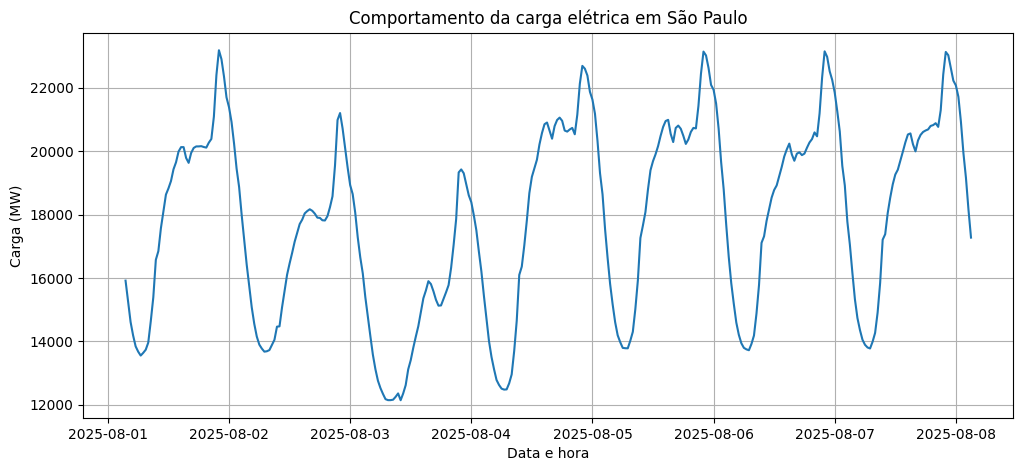

In [19]:
# Desenvolva aqui o DESAFIO 6

dados_desafio6 = pd.DataFrame(registros)

dados_desafio6["din_referenciautc"] = pd.to_datetime(
    dados_desafio6["din_referenciautc"]
)

# Gráfico 1 - Comportamento da carga ao longo do tempo

plt.figure(figsize=(12, 5))

plt.plot(
    dados_desafio6["din_referenciautc"],
    dados_desafio6["val_cargaglobal"]
)

plt.title("Comportamento da carga elétrica em São Paulo")
plt.xlabel("Data e hora")
plt.ylabel("Carga (MW)")
plt.grid(True)

plt.show()

A carga elétrica apresenta variações ao longo do período analisado, com momentos de maior e menor demanda. Os valores mais elevados ocorrem em determinados horários, enquanto em outros períodos a carga diminui.

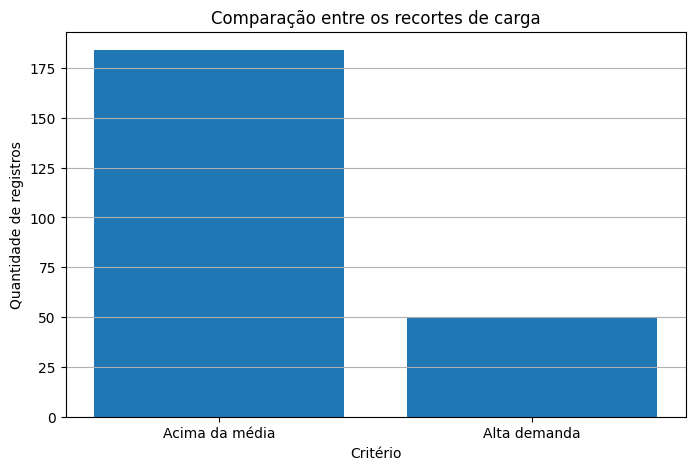

In [20]:
# Gráfico 2 - Comparação dos recortes

categorias = [
    "Acima da média",
    "Alta demanda"
]

quantidades = [
    len(dados_acima_media),
    len(alta_demanda)
]

plt.figure(figsize=(8, 5))

plt.bar(categorias, quantidades)

plt.title("Comparação entre os recortes de carga")
plt.xlabel("Critério")
plt.ylabel("Quantidade de registros")
plt.grid(axis="y")

plt.show()

O número de registros acima da média é maior que o número de registros classificados como alta demanda. Isso indica que estar acima da média é mais frequente, enquanto atingir mais de 90% da carga máxima ocorre com menor frequência.

## DESAFIO 7 — Síntese para o relatório

Crie uma variável `resumo_resultados` contendo pelo menos:

- região;
- período;
- quantidade de registros;
- carga mínima;
- carga máxima;
- carga média;
- mediana;
- limiar de alta demanda;
- quantidade e percentual de alta demanda;
- momento do pico;
- resultado do segundo critério.

A IA deverá receber **resultados produzidos por vocês**, e não substituir a análise.

In [21]:
# Exemplo de estrutura:
#
# resumo_resultados = f'''
# Região analisada: ...
# Período analisado: ...
# Quantidade de registros: ...
# Carga mínima: ...
# Carga máxima: ...
# Carga média: ...
# Mediana: ...
# Limiar de alta demanda: ...
# Registros de alta demanda: ...
# Percentual de alta demanda: ...
# Momento do pico: ...
# Segundo critério: ...
# '''
#
# print(resumo_resultados)

In [22]:
dados_desafio7 = pd.DataFrame(registros)

dados_desafio7["din_referenciautc"] = pd.to_datetime(
    dados_desafio7["din_referenciautc"]
)

# Indicadores yayyyy

regiao = dados_desafio7["cod_areacarga"].iloc[0]

periodo_inicio = dados_desafio7["dat_referencia"].min()
periodo_fim = dados_desafio7["dat_referencia"].max()

quantidade_registros = len(dados_desafio7)

carga_minima = dados_desafio7["val_cargaglobal"].min()
carga_maxima = dados_desafio7["val_cargaglobal"].max()
carga_media = dados_desafio7["val_cargaglobal"].mean()
mediana = dados_desafio7["val_cargaglobal"].median()

limiar_alta_demanda = carga_maxima * 0.90

alta_demanda = dados_desafio7[
    dados_desafio7["val_cargaglobal"] > limiar_alta_demanda
]

quantidade_alta_demanda = len(alta_demanda)

percentual_alta_demanda = (
    quantidade_alta_demanda / quantidade_registros
) * 100

indice_pico = dados_desafio7["val_cargaglobal"].idxmax()

momento_pico = dados_desafio7.loc[
    indice_pico, "din_referenciautc"
]

dados_acima_media = dados_desafio7[
    dados_desafio7["val_cargaglobal"] > carga_media
]

quantidade_acima_media = len(dados_acima_media)

percentual_acima_media = (
    quantidade_acima_media / quantidade_registros
) * 100

# Printando o negócio
resumo_resultados = f"""
Região analisada: {regiao}

Período analisado: {periodo_inicio} a {periodo_fim}

Quantidade de registros: {quantidade_registros}

Carga mínima: {carga_minima:.3f} MW

Carga máxima: {carga_maxima:.3f} MW

Carga média: {carga_media:.3f} MW

Mediana: {mediana:.3f} MW

Limiar de alta demanda (90% da carga máxima):
{limiar_alta_demanda:.3f} MW

Registros de alta demanda:
{quantidade_alta_demanda}

Percentual de alta demanda:
{percentual_alta_demanda:.2f}%

Momento do pico:
{momento_pico}

Segundo critério:
carga acima da média

Registros acima da média:
{quantidade_acima_media}

Percentual acima da média:
{percentual_acima_media:.2f}%
"""

print(resumo_resultados)


Região analisada: SP

Período analisado: 2025-08-01 a 2025-08-07

Quantidade de registros: 336

Carga mínima: 12139.253 MW

Carga máxima: 23185.312 MW

Carga média: 17870.829 MW

Mediana: 18199.128 MW

Limiar de alta demanda (90% da carga máxima):
20866.781 MW

Registros de alta demanda:
50

Percentual de alta demanda:
14.88%

Momento do pico:
2025-08-01 22:00:00+00:00

Segundo critério:
carga acima da média

Registros acima da média:
184

Percentual acima da média:
54.76%



# Relatório técnico com apoio do Gemini

No Colab:

1. abra **Secrets**;
2. crie `GEMINI_API_KEY`;
3. informe sua chave;
4. permita o acesso do notebook ao secret.

**Não coloque a chave diretamente no código.**

In [23]:
!pip -q install -U google-genai

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.5/56.5 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 37.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 259.7/259.7 kB 18.9 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires google-auth==2.49.0, but you have google-auth 2.57.0 which is incompatible.


In [24]:
from google.colab import userdata
from google import genai

GEMINI_API_KEY = userdata.get("GEMINI_API_KEY")
client = genai.Client(api_key=GEMINI_API_KEY)

## DESAFIO 8 — Geração do relatório

O relatório deve:

- usar os resultados calculados;
- apresentar os principais indicadores;
- destacar o pico e os períodos de alta demanda;
- comparar os dois critérios;
- não inventar causas;
- diferenciar observações de hipóteses;
- terminar com uma conclusão.

In [25]:
prompt = f'''
Atue como analista de dados do setor elétrico.

Produza um relatório técnico curto com base EXCLUSIVAMENTE nos resultados abaixo.

Não invente causas para as variações observadas.
Não apresente como fato explicações que não possam ser sustentadas pelos dados.
Diferencie claramente resultados observados de hipóteses.

Inclua:
1. caracterização do conjunto analisado;
2. principais indicadores;
3. análise dos períodos de alta demanda;
4. comparação com o segundo critério;
5. conclusão.

RESULTADOS DA EQUIPE:

{resumo_resultados}
'''

In [26]:
response_gemini = client.models.generate_content(
    model="gemini-3.6-flash",
    contents=prompt
)

print(response_gemini.text)

# Relatório Técnico: Análise da Carga de Energia Elétrica – Região SP

**Para:** Gestão / Equipe Técnica  
**De:** Analista de Dados do Setor Elétrico  
**Período Analisado:** 01/08/2025 a 07/08/2025  
**Abrangência:** Região SP  

---

### 1. Caracterização do Conjunto Analisado
O presente relatório avalia o comportamento da carga de energia elétrica na **Região SP** ao longo do período de **01/08/2025 a 07/08/2025**. O conjunto de dados consolidado totaliza **336 registros** temporais.

---

### 2. Principais Indicadores
Os dados estatísticos descritivos apurados para o período são exibidos a seguir:

*   **Carga Mínima:** 12.139,253 MW
*   **Carga Máxima (Pico):** 23.185,312 MW
*   **Carga Média:** 17.870,829 MW
*   **Mediana:** 18.199,128 MW

**Resultados Observados:**
*   A variação absoluta entre a carga mínima e a máxima no período foi de **11.046,059 MW**.
*   A mediana (18.199,128 MW) apresentou-se superior à média (17.870,829 MW), indicando uma ligeira concentração de registr

## DESAFIO 9 — Validação crítica

Compare o texto gerado pelo Gemini com os cálculos, DataFrames e gráficos.

Responda:

1. Os indicadores foram utilizados corretamente?
2. Há alguma afirmação que não pode ser confirmada pelos dados?
3. Houve interpretação exagerada ou causalidade não demonstrada?
4. Que alterações a equipe realizou no texto?

## Relatório final

Insira abaixo a versão final revisada pela equipe.

_Escreva aqui a versão final revisada._

---

## Entrega

O notebook deve apresentar:

- consulta à API executada;
- DataFrame criado;
- inspeção e organização dos dados;
- indicadores;
- pelo menos dois DataFrames derivados por critérios;
- percentuais;
- pelo menos dois gráficos;
- interpretações;
- síntese para a IA;
- relatório com apoio do Gemini;
- validação crítica;
- versão final revisada.

**Entregue somente este Notebook (.ipynb), com todas as células executadas e os resultados visíveis.**